# Introduction 

The Glasgow Royal Infirmary (GRI) cohort is a retrospective colorectal cancer (CRC) cohort of stage I-III patients from Prof. Joanne Edward's lab. We are interesting in modelling the clinical data associated with these patients in order to predict cancer recurrence and survival probabilities of patients with CRC.

The competing risk is any other cause of death that is not CRC death or CRC recurrence. The event of interest is CRC death and CRC recurrence. 

This file contains a simple data preprocessing, where we look at missing values and filter columns and rows. 

# Dataset

In [145]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import missingno as msno
from sksurv.linear_model import CoxPHSurvivalAnalysis

from helper import smart_fix_dtypes
from helper import clean_columns

pd.set_option("display.max_columns", None)


In [146]:
df = pd.read_excel("data/GRI_FullDataset.xlsx", na_values=["NaN", "nan", "NA", "NAN"])

In [ ]:
df

### Missigness

In [148]:
print(df.isna().sum().to_string())


TMA_order                            0
TMA_number                           0
CSS_months_2020                      0
UpdateJuly2020_a0_cd1_ncd2           3
neoadj1                              2
Thirtyday_mortality_2017             0
c0r1                                 2
CMS_Raheleh_withoutlabels          352
DFS_months_2020                     23
DFS_status_July2020                 22
DateofLastFollowUp01072020           0
date_recurrence_01072020            23
MMR_Status_Jen                      26
adj1                                 2
el0em1                               2
dofsurg                              0
dob                                  0
REC_n0_yes1                         20
DFS_months                         569
DFS_years                          569
Vital_status_confirmed             722
Notes                              618
PrimaryCOD                         412
Recurrence_local1_distant2          25
Local_recurrenceKK                  25
Distant_recurrenceKK     

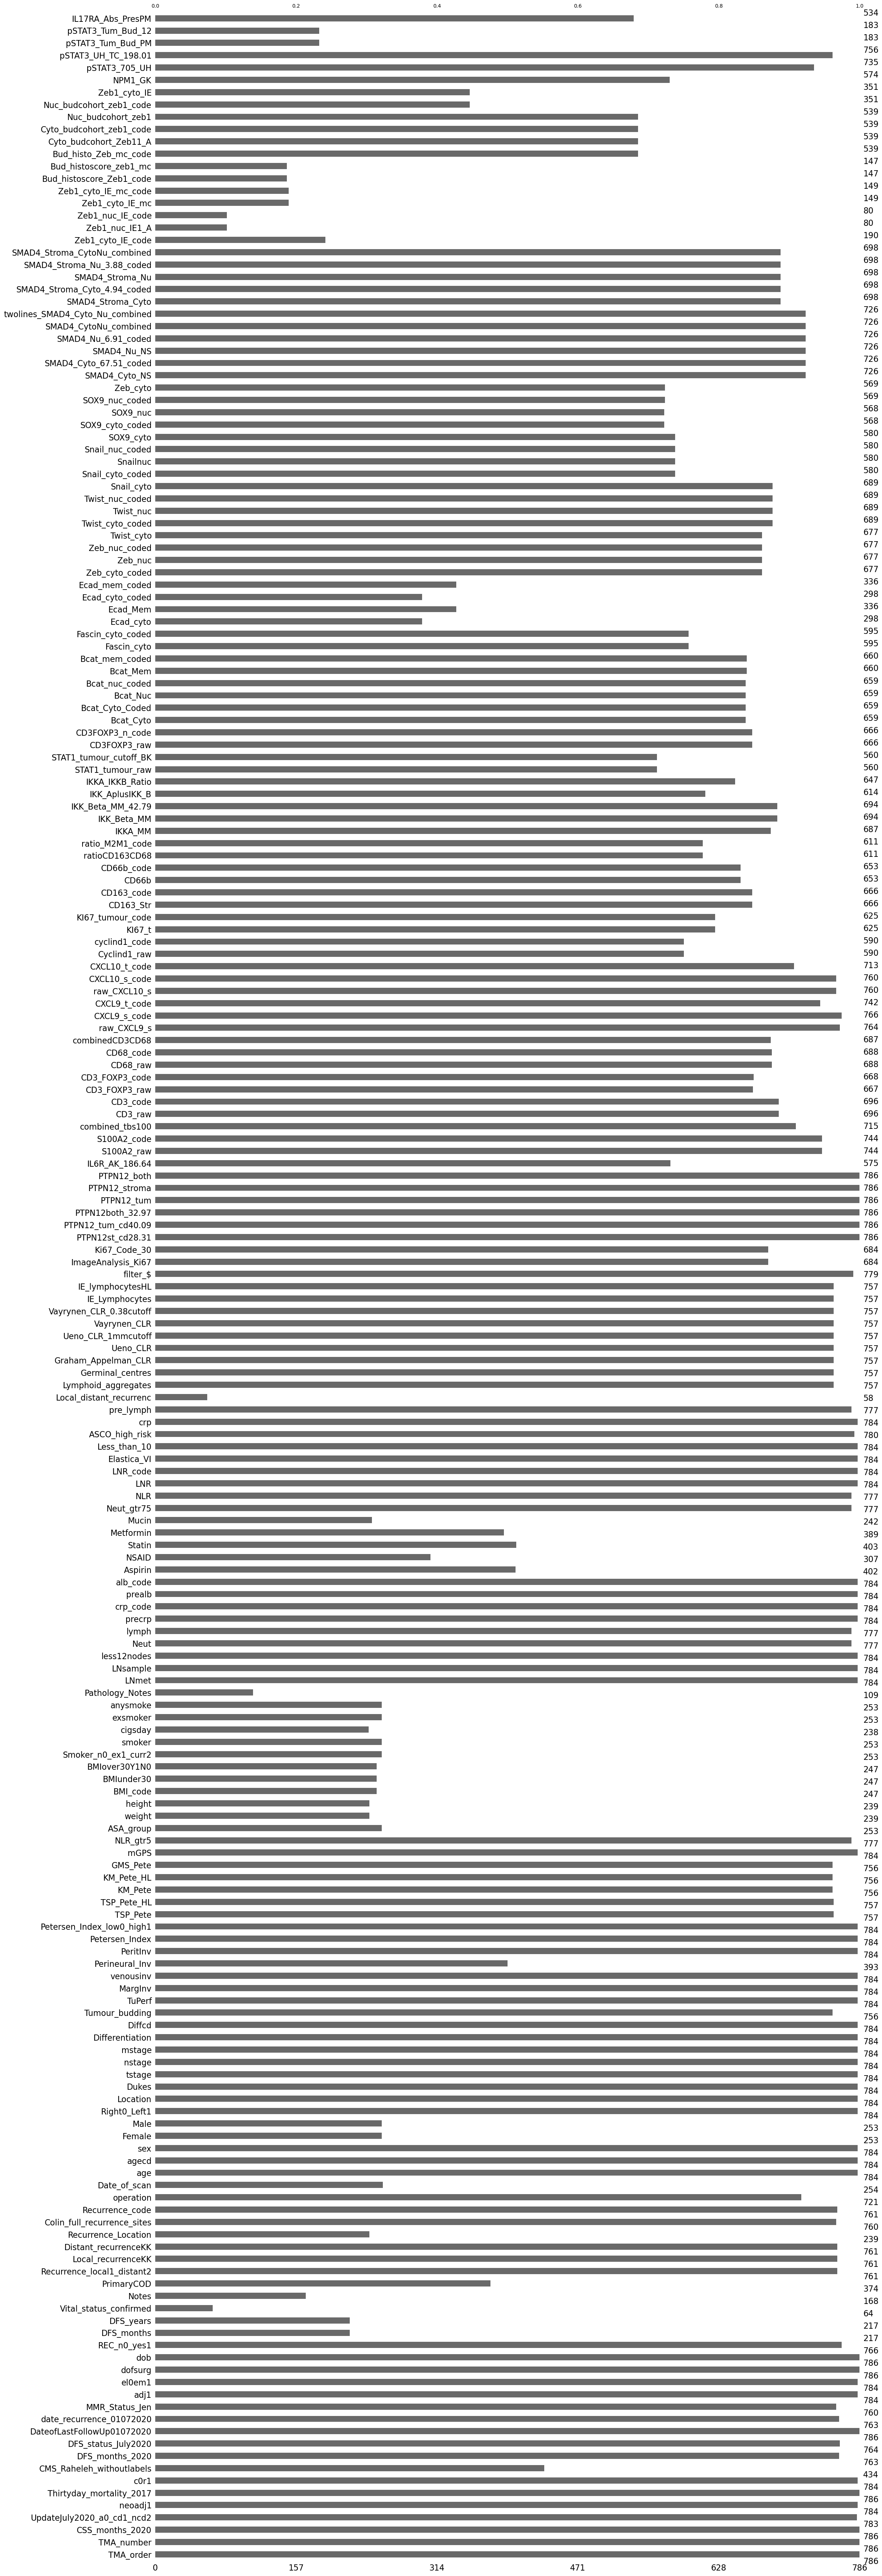

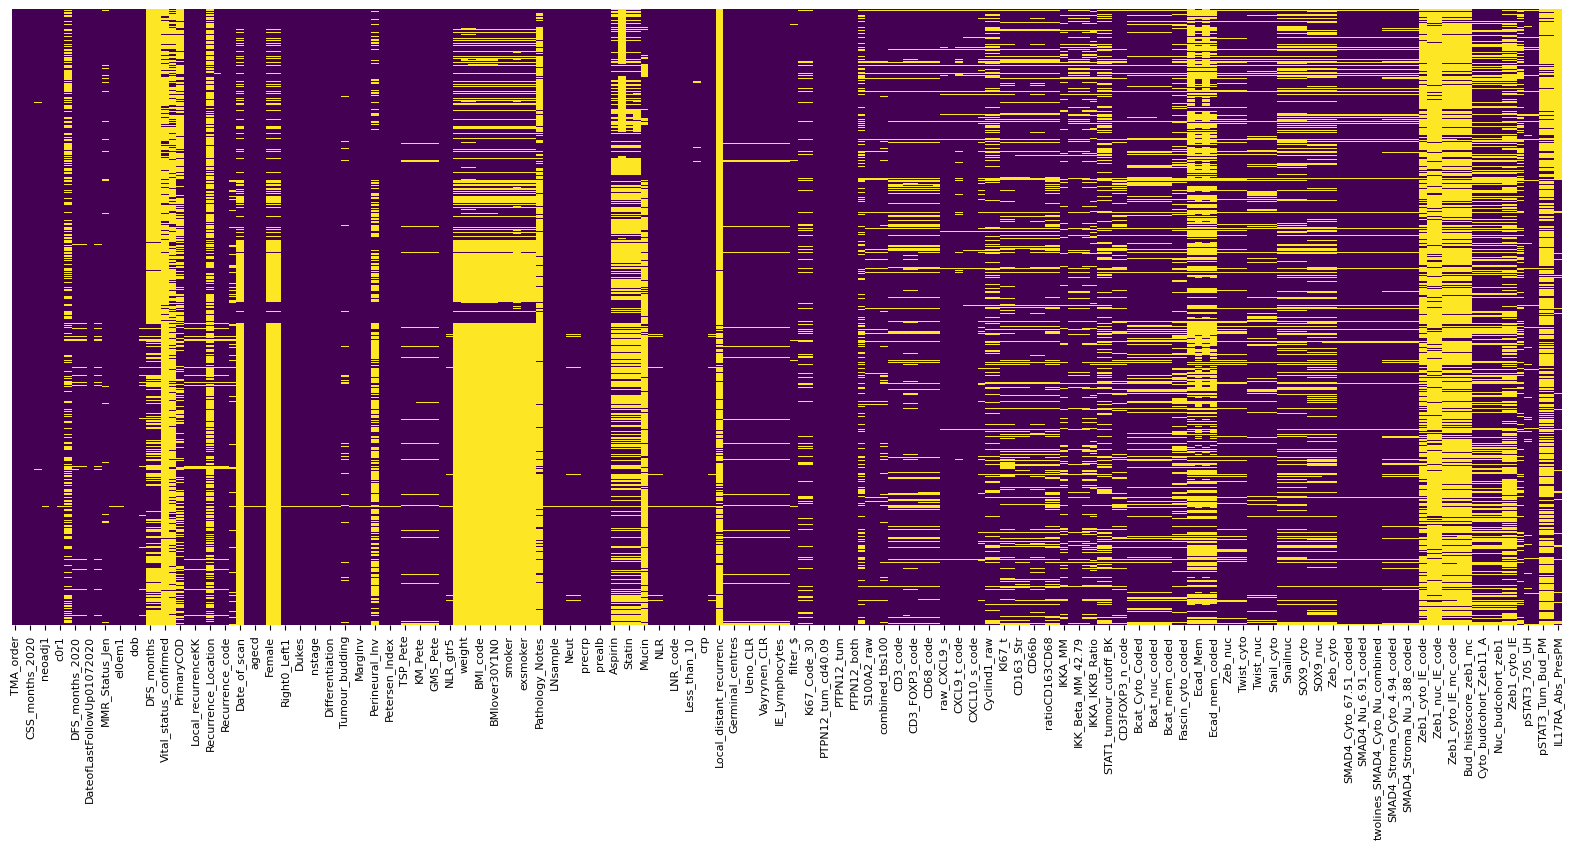

In [149]:
# Plot missigness
# Bar chart (missing counts per column)
msno.bar(df)
plt.show()

# Heatmap of missing-value correlations
#msno.heatmap(df)
#plt.show()

plt.figure(figsize=(20, 8))   # make the figure wide
sns.heatmap(df.isna(), cbar=False, cmap="viridis")

plt.xticks(rotation=90, fontsize=8)   # rotate column labels
plt.yticks([])                        # hide row labels (too many)
plt.show()

#### Preprocessing

Initial preprocessing includes exclusion criteria such not including those patients that have neoadjuvant therapy. 
Also, some patients gave the value 999 as NA, and the event is set as "12", instead of 0, 1 or 2.

In [150]:
df["UpdateJuly2020_a0_cd1_ncd2"].value_counts(dropna=False)

UpdateJuly2020_a0_cd1_ncd2
2.0     276
0.0     275
1.0     231
NaN       3
12.0      1
Name: count, dtype: int64

In [151]:
# looking at the one with 12 as value 
df[df["UpdateJuly2020_a0_cd1_ncd2"] == 12]

# it is commented in Notes that the person moved. It is probably alive when that happened and so the most appropiate is a 1 (alive) as status. 
# Also REC_no0_yes1 suggests that there is no recurrence
df.loc[df["UpdateJuly2020_a0_cd1_ncd2"] == 12, "UpdateJuly2020_a0_cd1_ncd2"] = 1


In [152]:
# Detecting some value of "999" what is inserted when NA
(df["neoadj1"] == 999).sum()

df["neoadj1"].value_counts(dropna=False)

print((df == 999).sum().to_string())

TMA_order                           0
TMA_number                          0
CSS_months_2020                     0
UpdateJuly2020_a0_cd1_ncd2          0
neoadj1                             5
Thirtyday_mortality_2017            0
c0r1                                0
CMS_Raheleh_withoutlabels           0
DFS_months_2020                     0
DFS_status_July2020                 0
DateofLastFollowUp01072020          0
date_recurrence_01072020            0
MMR_Status_Jen                      0
adj1                                2
el0em1                              0
dofsurg                             0
dob                                 0
REC_n0_yes1                         0
DFS_months                          0
DFS_years                           0
Vital_status_confirmed              0
Notes                               0
PrimaryCOD                          0
Recurrence_local1_distant2         25
Local_recurrenceKK                 25
Distant_recurrenceKK               24
Recurrence_L

In [153]:
# replace it with NA
df.replace(999, np.nan, inplace=True)


In [ ]:
# make a subset with those that contain neoadjuvant therapy 0
(df["neoadj1"] == 1).sum()
df = df[df["neoadj1"] == 0]
df.head()

In [155]:
## make the dates
data = df.copy()

# Convert dates from "dd.mm.yyyy" format
data["Date_of_scan"] = pd.to_datetime(df["Date_of_scan"], format="%d.%m.%Y", errors="coerce")
data["DateofLastFollowUp01072020"] = pd.to_datetime(df["DateofLastFollowUp01072020"], format="%d.%m.%Y", errors="coerce")
data["date_recurrence_01072020"] = pd.to_datetime(df["date_recurrence_01072020"], format="%d.%m.%Y", errors="coerce")
data["dofsurg"] = pd.to_datetime(df["dofsurg"], format="%d.%m.%Y", errors="coerce")
data["dob"] = pd.to_datetime(df["dob"], format="%d.%m.%Y", errors="coerce")

In [156]:
# make the operation labels correctly
data["operation"] = data["operation"].astype(str).str.upper()

data["operation"] = data["operation"].str.replace(r"EXT RIGH", "EXT RT", regex=True)
data["operation"] = data["operation"].str.replace(r"EXT RH", "EXT RT", regex=True)

data["operation"] = data["operation"].str.replace(r"PROCTOCO", "PANPROCT", regex=True)
data["operation"] = data["operation"].str.replace(r"PROCTECT", "PANPROCT", regex=True)

data["operation"] = data["operation"].str.replace(r"(?<!\w)APR\s*\?(?!\w)", "APR", regex=True)

print(data["operation"].unique())


['SUBTOTAL' 'LEFT' 'RIGHT' 'ANTERIOR' 'SIGMOID' 'HARTMANN' 'PANPROCT'
 'EXT RT' 'APR' 'LH+RH' 'TRANSVER' 'RH BSO T' 'NAN']


In [157]:

df2 = data.copy()

# Condition for NA rows in any of these columns
na_mask = df2[["Recurrence_local1_distant2", "REC_n0_yes1", "Colin_full_recurrence_sites"]].isna().any(axis=1)

# Apply the same logic as in R
df2.loc[na_mask, "Recurrence_local1_distant2"] = np.where(
    df2.loc[na_mask, "REC_n0_yes1"] == 0,
    0,
    df2.loc[na_mask, "Recurrence_local1_distant2"]
)

df2.loc[na_mask, "Colin_full_recurrence_sites"] = np.where(
    df2.loc[na_mask, "REC_n0_yes1"] == 0,
    0,
    df2.loc[na_mask, "Colin_full_recurrence_sites"]
)

df2.loc[na_mask, "REC_n0_yes1"] = np.where(
    df2.loc[na_mask, "Recurrence_local1_distant2"] == 0,
    0,
    df2.loc[na_mask, "REC_n0_yes1"]
)

# Create a new label for Recurrence_local1_distant2, if the label is == to 4, means that it had recurrence and we do not know where. 
na_mask2 = df2["Recurrence_local1_distant2"].isna()

df2.loc[na_mask2, "Recurrence_local1_distant2"] = np.where(
    df2.loc[na_mask2, "REC_n0_yes1"] == 1,
    4,
    df2.loc[na_mask2, "Recurrence_local1_distant2"]
)



### Basic demographic 

In [158]:
df2["sex"].value_counts(normalize=True) * 100

sex
1.0    55.38674
0.0    44.61326
Name: proportion, dtype: float64

In [159]:
df2["age"].mean()

np.float64(68.8646408839779)

In [160]:
## super important to calculate the ratio of limph nodes that are positive
df2["LNratio"] = np.where( df2["LNsample"] == 0, 0, (df2["LNmet"] / df2["LNsample"]).round(3))

# it might be actually not needed since it is already calculated as LNR

### Variables for competing risks

Basically it is the same as the event indicator, but if they had recurrence, they are treated like if they died by other causes.
It requires the last follow up information recorded in "UpdateJuly2020_a0_cd1_ncd2", and the Disease free status information from "DFS_status_July2020".
If it has had recurrence meaning DFS_status_July == 1, then that is our event of interest now.

Recurrence/died of cancer = event of interest

Alive without recurrence = censor

Died of other causes without recurrece = competing event



In [161]:
df2["Cmprsk_Status"] = df2["UpdateJuly2020_a0_cd1_ncd2"]
df2["Cmprsk_Status"] = np.where(df2["DFS_status_July2020"] == 1, 1,  df2["Cmprsk_Status"])

In [162]:
df2["Cmprsk_Status"].value_counts(normalize=True) * 100

Cmprsk_Status
2.0    35.041551
1.0    32.825485
0.0    32.132964
Name: proportion, dtype: float64

It is not easy to define the event of interest, since we have cases where they might have died of other causes but they have had recurrence as well. 
Since we are primarily interested in recurrence, we have to prioritize it. Therefore, if it has had recurrence, we would assign it the event of interest regardless of the other cause of death.

Some examples where the overall status, does not correspond with the disease free status:


In [ ]:
mask = df2["UpdateJuly2020_a0_cd1_ncd2"] != df2["DFS_status_July2020"]
df2.loc[mask, ["UpdateJuly2020_a0_cd1_ncd2", "DFS_status_July2020", "REC_n0_yes1", "Cmprsk_Status"]]

Before we get the complete cases we need to subset the dataset, or perform inputation. 

In [164]:
complete_cases = df2.dropna(axis = 0, how = 'any')
print(complete_cases)


Empty DataFrame
Columns: [TMA_order, TMA_number, CSS_months_2020, UpdateJuly2020_a0_cd1_ncd2, neoadj1, Thirtyday_mortality_2017, c0r1, CMS_Raheleh_withoutlabels, DFS_months_2020, DFS_status_July2020, DateofLastFollowUp01072020, date_recurrence_01072020, MMR_Status_Jen, adj1, el0em1, dofsurg, dob, REC_n0_yes1, DFS_months, DFS_years, Vital_status_confirmed, Notes, PrimaryCOD, Recurrence_local1_distant2, Local_recurrenceKK, Distant_recurrenceKK, Recurrence_Location, Colin_full_recurrence_sites, Recurrence_code, operation, Date_of_scan, age, agecd, sex, Female, Male, Right0_Left1, Location, Dukes, tstage, nstage, mstage, Differentiation, Diffcd, Tumour_budding, TuPerf, MargInv, venousinv, Perineural_Inv, PeritInv, Petersen_Index, Petersen_Index_low0_high1, TSP_Pete, TSP_Pete_HL, KM_Pete, KM_Pete_HL, GMS_Pete, mGPS, NLR_gtr5, ASA_group, weight, height, BMI_code, BMIunder30, BMIover30Y1N0, Smoker_n0_ex1_curr2, smoker, cigsday, exsmoker, anysmoke, Pathology_Notes, LNmet, LNsample, less12nodes

In [ ]:
df2


# Quality Performance Indicators (QPIs)
## Colorectal cancer quality performance indicator (QPI) documentation

https://publichealthscotland.scot/population-health/conditions-and-diseases/cancer/cancer-quality-performance-indicators-qpis/quality-performance-indicators-qpis/qpi-documentation/


https://publichealthscotland.scot/publications/colorectal-cancer-quality-performance-indicator-qpi-documentation/colorectal-cancer-quality-performance-indicator-qpi-documentation-1-april-2021-onwards/

01 May 2023 (Latest release)

National cancer quality performance indicators have been developed to support continuous quality improvement in cancer care (CEL 06 2012). NHS Boards are required to report these indicators against a clinically agreed indicator specific target as part of the mandatory national cancer quality programme. They have been developed collaboratively by North Cancer Alliance, South East Scotland Cancer Network, West of Scotland Cancer Network, Healthcare Improvement Scotland and PHS.

They are recorded to evaluate if patients with colorectal cancer are receiving a high standard of care. 

| **Field Name** | **Description**                                             | **Required for QPI(s)**              |
| -------------- | ----------------------------------------------------------- | ------------------------------------ |
| DATEIMAGELB    | Date of Imaging Large Bowel                                 | QPI 2                                |
| DIAGDATE       | Date of Diagnosis (Cancer)                                  | QPI 1, 2, 5, 7, 8, 9, 10, 11, 12, 16 |
| SITEPRIM       | Site of Origin of Primary Tumour (Cancer)                   | QPI 1, 7                             |
| FINSURGDATE    | Date of Final Definitive (or Only) Surgery                  | QPI 2, 7, 10, 11                     |
| PRESENT        | Presentation Type (Elective/Emergency)                      | QPI 1, 2, 7, 10                      |
| OPINTENT       | Intent of Surgery (Curative/Palliative)                     | QPI 1, 2, 5                          |
| REOPER         | Re-operation after definitive surgery                       | QPI 8                                |
| ANASLEAK       | Anastomotic Leak after surgery                              | QPI 9                                |
| CIRCMARGIN     | Circumferential Margin Involved (surgical specimen)         | QPI 7                                |
| LNEXAMINE      | Final Total Number of Lymph Nodes Examined                  | QPI 5                                |
| FINALN         | TNM Nodal Classification (Final)                            | QPI 11                               |
| FINALT         | TNM Tumour Classification (Final)                           | QPI 11                               |
| FINALM         | TNM Metastasis Classification (Final)                       | QPI 11                               |
| NEOONC         | Neo-Adjuvant Oncology Treatment Type                        | QPI 11                               |
| ADJONC         | Primary/Palliative/Adjuvant Oncology Treatment Type         | QPI 1                                |
| ADJONC\_DATE   | Date Primary/Palliative/Adjuvant Oncology Treatment Started | QPI 11                               |
| LIVERDIAGDATE  | Date of Liver Imaging confirming liver mets                 | QPI 15                               |
| HPBMDT         | Referral to HPB MDT (liver mets patients)                   | QPI 15                               |
| BRAF           | BRAF mutation status                                        | QPI 16                               |
| MSISTATUS      | Microsatellite Instability (MSI) Status                     | QPI 16                               |
| IHCSTATUS      | Mismatch Repair (MMR IHC)                                   | QPI 16                               |
| GENETICS       | Genetics Referral                                           | QPI 16                               |
| TRIAL          | Patient entered into Clinical Trial                         | Generic QPIs                         |

The QPI's names are the following:

| **QPI** | **Name**                                                      |
| ------- | ------------------------------------------------------------- |
| QPI 1   | Radiological Diagnosis of Colorectal Cancer                   |
| QPI 2   | Pre-operative Imaging of Colon                                |
| QPI 3   | *Retired* (Staging Laparoscopy – removed in earlier versions) |
| QPI 4   | Pre-operative MRI in Rectal Cancer                            |
| QPI 5   | Lymph Node Yield                                              |
| QPI 6   | Pre-operative Radiotherapy in Rectal Cancer                   |
| QPI 7   | Clear Surgical Margins                                        |
| QPI 8   | Re-operation                                                  |
| QPI 9   | Anastomotic Leak                                              |
| QPI 10  | Emergency Surgery                                             |
| QPI 11  | Pathological Staging                                          |
| QPI 12  | Adjuvant Chemotherapy in Stage III Colon Cancer               |
| QPI 13  | Adjuvant Radiotherapy in Rectal Cancer                        |
| QPI 14  | Adjuvant Chemotherapy in Rectal Cancer                        |
| QPI 15  | Imaging for Liver Metastases                                  |
| QPI 16  | Molecular Pathological Markers                                |

In our dataset we have lots of more variables, some of them can be understood as extenstion of the standard QPI's. For instance the GRI contains more genertic and pathology variables, which in the future could be converted into the standard practise.


In our dataset:

| **GRI column**            | **QPI dataset variable**                    | **QPI No.**                         | **QPI Name**                                                                     |
| ---------------------------------- | ------------------------------------------- | ----------------------------------- | -------------------------------------------------------------------------------- |
| `UpdateJuly2020_a0_cd1_ncd2`       | Treatment update / recurrence status fields | QPI 12                              | Adjuvant Chemotherapy in Stage III Colon Cancer                                  |
| `Thirtyday_mortality_2017`         | 30-day mortality (audit item, not a QPI)    | –                                   | –                                                                                |
| `MMR_Status_Jen`                   | `MSISTATUS` / `IHCSTATUS`                   | QPI 16                              | Molecular Pathological Markers                                                   |
| `BRAF`                   | `BRAF`                   | QPI 16                              | Molecular Pathological Markers                                                   |
| `dofsurg` (date of surgery)        | `FINSURGDATE`                               | QPI 2, 7, 10, 11                    | Definitive Surgery / Surgical Margins / Emergency Surgery / Pathological Staging |
| `operation`                        | `OPINTENT`                                  | QPI 1, 2, 5                         | Surgical Intent (Curative/Palliative)                                            |
| `sex` / `Female` / `Male`          | `SEX`                                       | Background (not QPI)                | –                                                                                |
| `Location` / `Right0_Left1`        | `SITEPRIM`                                  | QPI 1, 7                            | Radiological Diagnosis / Clear Surgical Margins                                  |
| `tstage` / `nstage` / `mstage`     | `FINALT` / `FINALN` / `FINALM`              | QPI 11                              | Pathological Staging                                                             |
| `Differentiation`                  | `DIFFERENT` (if present)                      | Not core QPI (but pathology detail) | –                                                                                |
| `LNratio` | `LNEXAMINE`                                 | QPI 5                               | Lymph Node Yield                                                                 |
| `MargInv`                          | `CIRCMARGIN`                                | QPI 7                               | Clear Surgical Margins                                                           |
| `Recurrence_local1_distant2`       | Recurrence coding                           | QPI 12–14                           | Adjuvant therapy follow-up                                                       |
| `PrimaryCOD`                       | Cause of death                              | Background (not QPI)                | –                                           |


Additionally we have the BRAF mutation status.

Lots of recurrence and competing risk status do not appear in the QPI's but they are quite useful


Regarding the genetics or QPI 16, we miss MLH1 in GRI. Overall QPI miss lots of important variables like tumor budding etc. 


Let's add the mutation data

In [ ]:
mutations = pd.read_excel("data/Mutations_GRI.xlsx", na_values=["NaN", "nan", "NA", "NAN"])

mutations

In [167]:
df3 = df2.merge(mutations, on="TMA_order") 

Which of te QPIs can be predictive?

In [168]:
qpis = [
    #"UpdateJuly2020_a0_cd1_ncd2",
    #"Thirtyday_mortality_2017", # not for prediction and part od DFS_months
    "MMR_Status_Jen",
    "BRAF",
    #"dofsurg", #not for prediction
    #"operation", # operation has causal blind spots
    "sex",
    "Location", "Right0_Left1",
    "tstage", "nstage", "mstage",
    "Differentiation",
    "LNratio",
    "MargInv",
    #"Recurrence_local1_distant2", #not for prediction
    #"PrimaryCOD", # removing this since we gave cmprsk status
    "DFS_months_2020",
    #"DFS_status_July2020", # moved to Cmprsk_Status
    "Cmprsk_Status"
]

df_qpis = df3[qpis]

In [ ]:
df_qpis

In [170]:
print(df_qpis.isna().sum().to_string())


MMR_Status_Jen     19
BRAF               15
sex                 0
Location            0
Right0_Left1        0
tstage              0
nstage              0
mstage              0
Differentiation     5
LNratio             0
MargInv             0
DFS_months_2020    21
Cmprsk_Status       2


In [171]:
#sns.heatmap(df_qpis.isna(), cbar=False, cmap="viridis")

df_qpis_short = df_qpis.dropna(axis = 0)

print(df_qpis.shape)   


(724, 13)


Just as an example... this would require proper missing data inputation.

### Remove columns that we do not need

These are columns highly missing (smoke, weight...), like >50%





In [172]:
df3["ASA_group"].isna().sum()

np.int64(508)

In [ ]:
df3[["LNratio", "LNR"]]

df3["LNratio"].equals(df3["LNR"])

#print(df3[["LNratio", "LNR"]])

diff_mask = df3["LNratio"] != df3["LNR"]
df3.loc[diff_mask, ["LNratio", "LNR"]]

# we shall then keep the LNratio

In [174]:
print(df3.columns.to_list())

['TMA_order', 'TMA_number', 'CSS_months_2020', 'UpdateJuly2020_a0_cd1_ncd2', 'neoadj1', 'Thirtyday_mortality_2017', 'c0r1', 'CMS_Raheleh_withoutlabels', 'DFS_months_2020', 'DFS_status_July2020', 'DateofLastFollowUp01072020', 'date_recurrence_01072020', 'MMR_Status_Jen', 'adj1', 'el0em1', 'dofsurg', 'dob', 'REC_n0_yes1', 'DFS_months', 'DFS_years', 'Vital_status_confirmed', 'Notes', 'PrimaryCOD', 'Recurrence_local1_distant2', 'Local_recurrenceKK', 'Distant_recurrenceKK', 'Recurrence_Location', 'Colin_full_recurrence_sites', 'Recurrence_code', 'operation', 'Date_of_scan', 'age', 'agecd', 'sex', 'Female', 'Male', 'Right0_Left1', 'Location', 'Dukes', 'tstage', 'nstage', 'mstage', 'Differentiation', 'Diffcd', 'Tumour_budding', 'TuPerf', 'MargInv', 'venousinv', 'Perineural_Inv', 'PeritInv', 'Petersen_Index', 'Petersen_Index_low0_high1', 'TSP_Pete', 'TSP_Pete_HL', 'KM_Pete', 'KM_Pete_HL', 'GMS_Pete', 'mGPS', 'NLR_gtr5', 'ASA_group', 'weight', 'height', 'BMI_code', 'BMIunder30', 'BMIover30Y1N0'

We can drop some covariates that are coded version of continues variables. There is one coded version per each continous biomarker. 

We can also drop treatment variables, since including them as predictors would cause causal blind spots, immortal time bias, etc. 

Variables used to calculate DFS or competing risks status are also not longer needed. 

Some varibles such weight, height and BMI are highly missing and then we can remove them. 


In [175]:
df4 = df3.drop(labels=['TMA_number',"CSS_months_2020", "UpdateJuly2020_a0_cd1_ncd2", "neoadj1", "Thirtyday_mortality_2017",
                 "CMS_Raheleh_withoutlabels", "DFS_status_July2020", 'DateofLastFollowUp01072020', 'date_recurrence_01072020', 
                 'dofsurg', 'dob', 'REC_n0_yes1', 'DFS_months', 'DFS_years', "Vital_status_confirmed", "Pathology_Notes", 'Notes', 'PrimaryCOD', 'Local_recurrenceKK', 
                 'Distant_recurrenceKK', 'Recurrence_Location', 'Recurrence_code', 'operation', 'Date_of_scan', 
                 'agecd','Female', 'Male','Diffcd', 'Petersen_Index_low0_high1', 'TSP_Pete_HL', 'KM_Pete_HL', 'weight', 'height', 'BMI_code', 'BMIunder30', 
                 'BMIover30Y1N0', 'Smoker_n0_ex1_curr2', 'smoker', 'cigsday', 'exsmoker', 'anysmoke','LNmet', 'LNsample', 'less12nodes',
                 'crp_code', 'alb_code', 'Aspirin', 'NSAID', 'Statin', 'Metformin', 'Mucin', 'NLR_gtr5', 'Neut_gtr75','LNR_code', 'Less_than_10', 
                 'ASCO_high_risk', 'Ueno_CLR_1mmcutoff', 'Vayrynen_CLR_0.38cutoff', 'IE_lymphocytesHL', 'filter_$', 'Ki67_Code_30', 'PTPN12st_cd28.31',	
                 'PTPN12_tum_cd40.09',	'PTPN12both_32.97',
                 # remove all same value
                 'mstage',
                 # remove duplicates
                 'LNR',
                 # remove ratios
                 'ratioCD163CD68', 'ratio_M2M1_code', 'IKKA_IKKB_Ratio', 'NLR',
                 # remove redundant
                 "Right0_Left1", "c0r1",
                 # remove composites
                 "Petersen_Index", "KM_Pete", "GMS_Pete", "mGPS", "IKK_AplusIKK_B",
                 # remove unclear definitions
                 "Graham_Appelman_CLR", "Ueno_CLR", "Vayrynen_CLR",
                 # coded versions of raw and combinations:
                 'S100A2_code', 'combined_tbs100', 'CD3_code', 'CD3_FOXP3_code', 'CD68_code', 'combinedCD3CD68', 'CXCL9_s_code', 'CXCL9_t_code',
                 'CXCL10_s_code', 'CXCL10_t_code', 'cyclind1_code', 'KI67_tumour_code', 'CD163_code', 'CD66b_code',
                 'STAT1_tumour_cutoff_BK',  'CD3FOXP3_n_code', 'Bcat_Cyto_Coded', 'Bcat_nuc_coded', 'Bcat_mem_coded', 'Fascin_cyto_coded', 
                 'Ecad_cyto_coded', 'Ecad_mem_coded', 'Zeb_cyto_coded','Zeb_nuc_coded', 'Twist_cyto_coded', 'IKK_Beta_MM_42.79',
                 'Twist_nuc_coded', 'Snail_cyto_coded', 'Snail_nuc_coded', 'SOX9_cyto_coded', 'SOX9_nuc_coded',
                 'SMAD4_Cyto_67.51_coded', 'SMAD4_Nu_6.91_coded', 'SMAD4_CytoNu_combined', 'twolines_SMAD4_Cyto_Nu_combined', 
                 'SMAD4_Stroma_Cyto_4.94_coded', 'SMAD4_Stroma_Nu_3.88_coded', 'SMAD4_Stroma_CytoNu_combined', 'Zeb1_cyto_IE_code', 
                 'Zeb1_cyto_IE_mc_code', 'Bud_histoscore_Zeb1_code', 'Bud_histo_Zeb_mc_code', 'Cyto_budcohort_zeb1_code', 
                 'Nuc_budcohort_zeb1_code', 'pSTAT3_UH_TC_198.01', 'pSTAT3_Tum_Bud_12' ], axis=1)

                

For IL6 we only have a coded version so we leave it. 

Maybe some ratios should be removed too. 

In [ ]:
df4

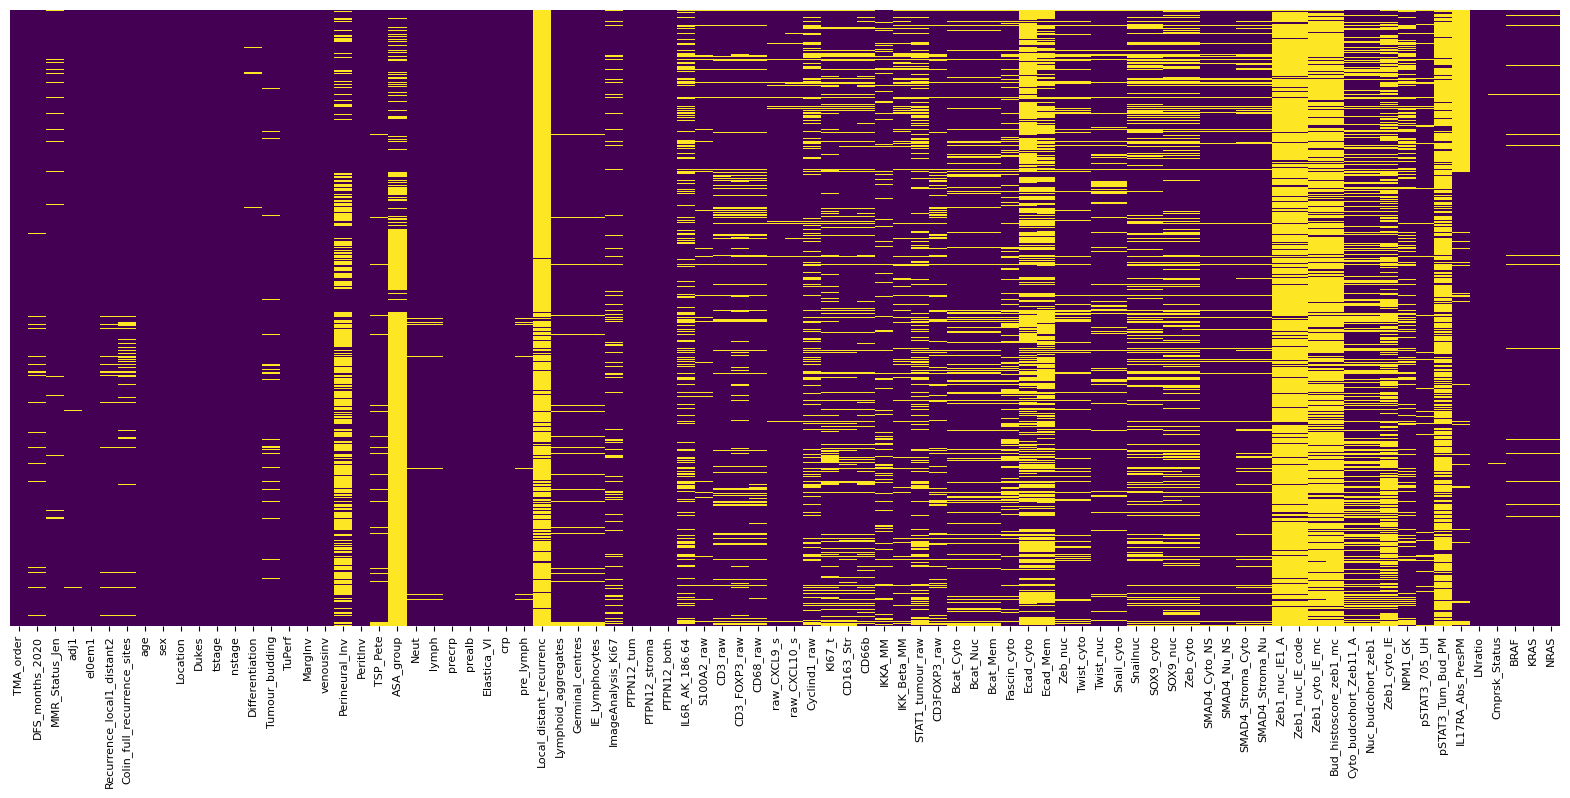

In [177]:
plt.figure(figsize=(20, 8))
sns.heatmap(df4.isna(), cbar=False, cmap="viridis")

plt.xticks(rotation=90, fontsize=8)  
plt.yticks([])         
plt.show()

Also removing those columns where we have more than 50% of missing values, since we will perform MICE. 

In [178]:

df4.shape


(724, 86)

In [179]:
k = int(np.ceil(0.5 * df4.shape[0]))  # required non-NA per row
k

362

In [ ]:
df5 = df4.dropna(axis=1, thresh=k)
df5

In [181]:

#dropped columns
df4.columns.difference(df5.columns)


Index(['ASA_group', 'Bud_histoscore_zeb1_mc', 'Ecad_Mem', 'Ecad_cyto',
       'Local_distant_recurrenc', 'Perineural_Inv', 'Zeb1_cyto_IE',
       'Zeb1_cyto_IE_mc', 'Zeb1_nuc_IE1_A', 'Zeb1_nuc_IE_code',
       'pSTAT3_Tum_Bud_PM'],
      dtype='object')

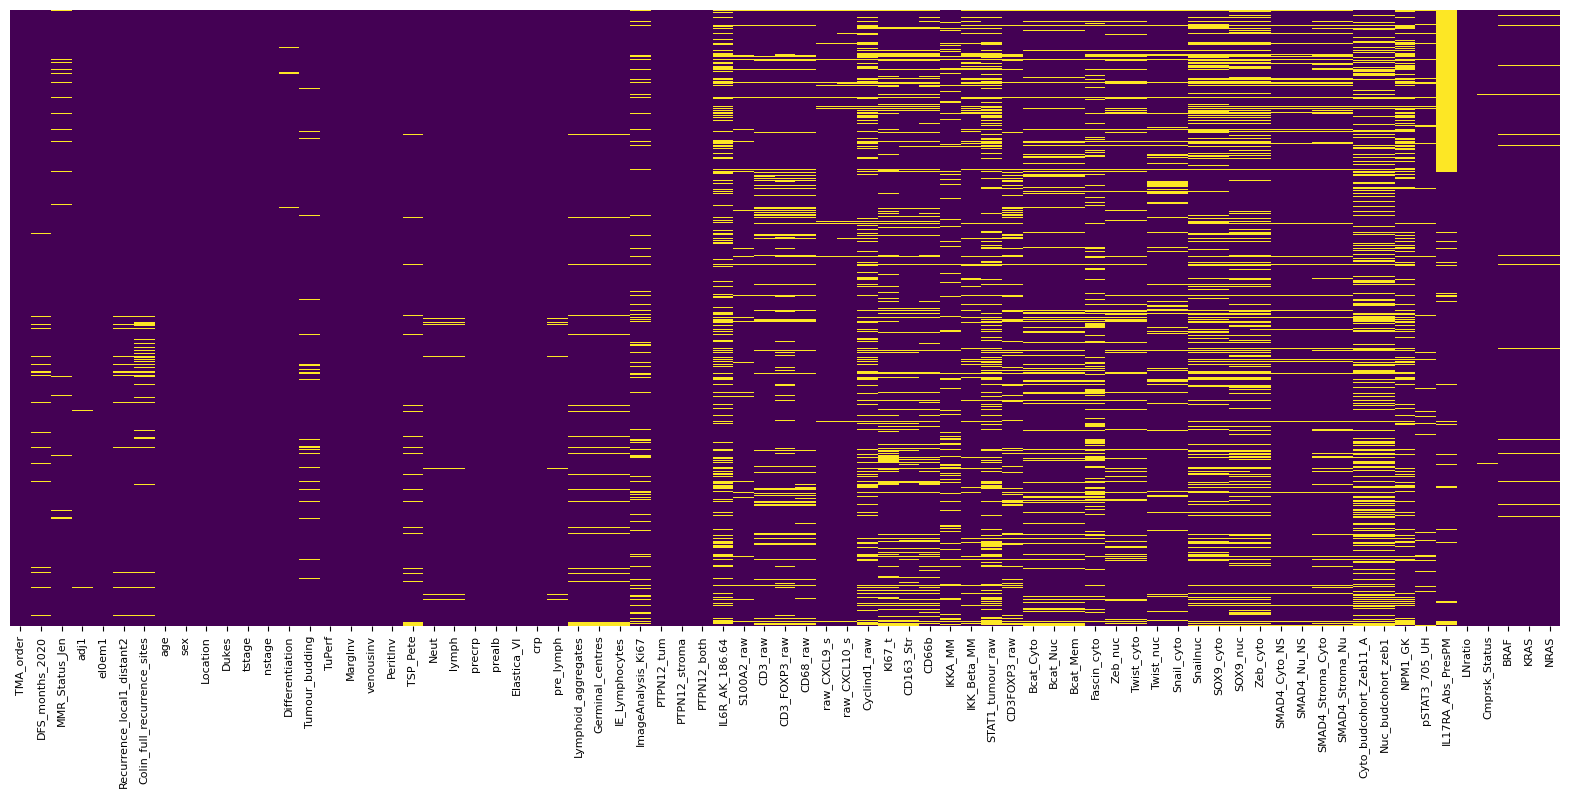

In [182]:
plt.figure(figsize=(20, 8))  
sns.heatmap(df5.isna(), cbar=False, cmap="viridis")

plt.xticks(rotation=90, fontsize=8)   
plt.yticks([])               
plt.show()

However the columns might not be with the correct type

In [ ]:
df5.dtypes
df5.info()

In [184]:
df6 = smart_fix_dtypes(df5, cat_threshold=12)
#print(df5.dtypes)
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 75 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   TMA_order                    724 non-null    int64   
 1   DFS_months_2020              703 non-null    float64 
 2   MMR_Status_Jen               705 non-null    category
 3   adj1                         722 non-null    boolean 
 4   el0em1                       724 non-null    boolean 
 5   Recurrence_local1_distant2   709 non-null    category
 6   Colin_full_recurrence_sites  686 non-null    category
 7   age                          724 non-null    float64 
 8   sex                          724 non-null    boolean 
 9   Location                     724 non-null    category
 10  Dukes                        724 non-null    category
 11  tstage                       724 non-null    category
 12  nstage                       724 non-null    category
 13  Diffe

Some further organization of values in certain columns:

In [ ]:
df6["Differentiation"].value_counts(dropna=False)

Map considering the recommendations in the QPIs:

In [186]:
_map = { 
    # Well/Moderate
    "well": "Well/Moderate", "welll": "Well/Moderate",
    "mod": "Well/Moderate", "moderate": "Well/Moderate",
    "mod/well": "Well/Moderate", "well/mod": "Well/Moderate",

    # Poor / undiff
    "poor": "Poor/Undiff", "mod/poor": "Poor/Undiff", "poor/mod": "Poor/Undiff", "undiff": "Poor/Undiff",

    # Mucinous
    "mucin": "Mucinous", "mucinous": "Mucinous", "muscious": "Mucinous",
}

# normalize to lowercase first, then map
s = df6["Differentiation"].astype(str).str.strip().str.lower()
df6["Differentiation"] = s.map(_map)

# quick check
print(df6["Differentiation"].value_counts(dropna=False))

Differentiation
Well/Moderate    641
Poor/Undiff       76
NaN                5
Mucinous           2
Name: count, dtype: int64


In [ ]:
df6["TSP_Pete"].value_counts(dropna=False)

In [ ]:
df6["tstage"].value_counts(dropna=False)

In [ ]:
df6["MMR_Status_Jen"].value_counts(dropna=False)

In [ ]:
df6.columns

In [191]:
#df6.to_csv("data/GRI_preprocess-1.csv")

### Metadata

We can create some metadata

Sources:

https://pmc.ncbi.nlm.nih.gov/articles/PMC8580263/

https://www.nature.com/articles/s41598-023-28631-y


QPIS data


In [215]:
COL_META = {
    "TMA_order": {"name": "TMA_Order", "origin": "Clinical", "qpis": "no", "collection": "research"},
    "DFS_months_2020": {"name": "Disease_Free_Survival_Months", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "adj1": {"name": "Adjuvant_Therapy", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "el0em1": {"name": "Emergency_Surgery", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "Recurrence_local1_distant2": {"name": "Recurrence_Code_Local1_Distant2", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "Colin_full_recurrence_sites": {"name": "Recurrence_Sites", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "age": {"name": "Age", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "sex": {"name": "Sex", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "Location": {"name": "Tumour_Location", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "Dukes": {"name": "Dukes_Stage", "origin": "Staging", "qpis": "no", "collection": "routine"},
    "tstage": {"name": "T_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "nstage": {"name": "N_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "mstage": {"name": "M_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "Cmprsk_Status": {"name": "Competing_Risk_Status", "origin": "Clinical", "qpis": "yes", "collection": "research"},

    # blood - Laboratory
    "Neut": {"name": "Neutrophils", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "lymph": {"name": "Lymphocytes", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "precrp": {"name": "Preoperative_CRP", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "prealb": {"name": "Preoperative_Albumin", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "crp": {"name": "CRP", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "pre_lymph": {"name": "Preoperative_Lymphocytes", "origin": "Laboratory", "qpis": "no", "collection": "routine"},

    # pathology 
    "Lymphoid_aggregates": {"name": "Lymphoid_Aggregates", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "Germinal_centres": {"name": "Germinal_Centres", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "IE_Lymphocytes": {"name": "Intraepithelial_Lymphocytes", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "ImageAnalysis_Ki67": {"name": "Ki67_Image_Analysis", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "Differentiation": {"name": "Histological_Grade", "origin": "Pathology", "qpis": "yes", "collection": "routine"},
    "Tumour_budding": {"name": "Tumour_Budding", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "TuPerf": {"name": "Tumour_Perforation", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "MargInv": {"name": "Margin_Invasion", "origin": "Pathology", "qpis": "yes", "collection": "routine"}, # if qpis then routine
    "venousinv": {"name": "Venous_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "PeritInv": {"name": "Peritoneal_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "TSP_Pete": {"name": "Tumour_Stroma_Percentage", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "LNratio": {"name": "Lymph_Node_Ratio", "origin": "Pathology", "qpis": "yes", "collection": "research"},
    "Elastica_VI": {"name": "Elastica_Venous_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "MMR_Status_Jen": {"name": "MMR_Status", "origin": "Pathology", "qpis": "yes", "collection": "routine"},

    # multiplex
    "CD3_raw": {"name": "CD3_Raw", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD3_FOXP3_raw": {"name": "CD3_FOXP3_Raw", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD68_raw": {"name": "CD68_Raw", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD163_Str": {"name": "CD163_Stroma", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD66b": {"name": "CD66b", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD3FOXP3_raw": {"name": "CD3FOXP3_Raw", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},

    # origin is RNAScope (Kat  modification)
    "raw_CXCL9_s": {"name": "CXCL9_Raw", "origin": "RNAScope", "qpis": "no", "collection": "research"},
    "raw_CXCL10_s": {"name": "CXCL10_Raw", "origin": "RNAScope", "qpis": "no", "collection": "research"},

    # inmunohistochemistry:
    "PTPN12_tum": {"name": "PTPN12_Tumour", "origin": "IHC", "qpis": "no", "collection": "research"},
    "PTPN12_stroma": {"name": "PTPN12_Stroma", "origin": "IHC", "qpis": "no", "collection": "research"},
    "PTPN12_both": {"name": "PTPN12_Combined", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IL6R_AK_186.64": {"name": "IL6R_AK_186_64", "origin": "IHC", "qpis": "no", "collection": "research"},
    "S100A2_raw": {"name": "S100A2_Raw", "origin": "IHC", "qpis": "no", "collection": "research"},

    "Cyclind1_raw": {"name": "CyclinD1_Raw", "origin": "IHC", "qpis": "no", "collection": "research"},
    "KI67_t": {"name": "Ki67_Tumour", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IKKA_MM": {"name": "IKK_Alpha_MM", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IKK_Beta_MM": {"name": "IKK_Beta_MM", "origin": "IHC", "qpis": "no", "collection": "research"},
    "STAT1_tumour_raw": {"name": "STAT1_Tumour_Raw", "origin": "IHC", "qpis": "no", "collection": "research"},

    "Bcat_Cyto": {"name": "BetaCatenin_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Bcat_Nuc": {"name": "BetaCatenin_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Bcat_Mem": {"name": "BetaCatenin_Membranous", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Fascin_cyto": {"name": "Fascin_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Zeb_nuc": {"name": "ZEB1_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Twist_cyto": {"name": "Twist_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Twist_nuc": {"name": "Twist_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Snail_cyto": {"name": "Snail_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Snailnuc": {"name": "Snail_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SOX9_cyto": {"name": "SOX9_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SOX9_nuc": {"name": "SOX9_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Zeb_cyto": {"name": "ZEB1_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Cyto_NS": {"name": "SMAD4_Cytoplasmic_NS", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Nu_NS": {"name": "SMAD4_Nuclear_NS", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Stroma_Cyto": {"name": "SMAD4_Stroma_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Stroma_Nu": {"name": "SMAD4_Stroma_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Cyto_budcohort_Zeb11_A": {"name": "BudCohort_ZEB1_Cytoplasmic_A", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Nuc_budcohort_zeb1": {"name": "BudCohort_ZEB1_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "NPM1_GK": {"name": "NPM1_GK", "origin": "IHC", "qpis": "no", "collection": "research"},
    "pSTAT3_705_UH": {"name": "pSTAT3_Y705_UH", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IL17RA_Abs_PresPM": {"name": "IL17RA_Presence", "origin": "IHC", "qpis": "no", "collection": "research"},

    # genetics
    "BRAF": {"name": "BRAF_Mutation", "origin": "Genetics", "qpis": "yes", "collection": "routine"},
    "KRAS": {"name": "KRAS_Mutation", "origin": "Genetics", "qpis": "no", "collection": "research"},
    "NRAS": {"name": "NRAS_Mutation", "origin": "Genetics", "qpis": "no", "collection": "research"},
}


In [216]:
### Updating metadata file
meta_df = pd.DataFrame.from_dict(COL_META).T.rename(columns={"name": "New Data Item", "origin": "Origin", "qpis": "Qpis", "collection": "Collection"})

meta_df

,New Data Item,Origin,Qpis,Collection
TMA_order,TMA_Order,Clinical,no,research
DFS_months_2020,Disease_Free_Survival_Months,Clinical,yes,routine
adj1,Adjuvant_Therapy,Clinical,no,routine
el0em1,Emergency_Surgery,Clinical,no,routine
Recurrence_local1_distant2,Recurrence_Code_Local1_Distant2,Clinical,no,routine
...,...,...,...,...
pSTAT3_705_UH,pSTAT3_Y705_UH,IHC,no,research
IL17RA_Abs_PresPM,IL17RA_Presence,IHC,no,research
BRAF,BRAF_Mutation,Genetics,yes,routine
KRAS,KRAS_Mutation,Genetics,no,research


In [217]:
## old metadata
meta2 = pd.read_excel("data/GRI_FullDataset.xlsx", sheet_name = "MetaData")

meta2.head()

,Data Item,Present in SESCD,Present in SOCCS,Present SMR06,DERIVED,Data Item Description,Data Item Entry,Units,Notes
0,TMA_order,NaN,NaN,NaN,NaN,Tissue Mircoarray (TMA) order,NaN,integer,TMAs have hundreds of tissue samples arrayed o...
1,TMA_number,NaN,NaN,NaN,NaN,Tissue Mircoarray (TMA) number,NaN,character,The number given to Microarray slide patient t...
2,CSS_months_2020,?DODeath_FINAL AND AnyRecurrenceDate,NaN,NaN,NaN,Cancer Specific Survival in Months,NaN,integer,Number of months from date of surgery (dofsurg...
3,UpdateJuly2020_a0_cd1_ncd2,eventall AND event_CRC AND event_other,NaN,NaN,NaN,Event Indicator,"0 == Alive, 1 == Cancer Cause of Death, 2 == O...",integer,"Patient event indicator, or status, as of July..."
4,neoadj1,NaN,NaN,NaN,NaN,Neoadjuvant Therapy,"0 == not received neoadjuvant, 1 == received n...",binary,"Neoadj == chemo/radio-therapy before surgery, ..."


In [218]:
## merge
meta3 = pd.merge(meta_df, meta2[["Data Item", "Data Item Description", "Data Item Entry", "Notes"]], right_on= "Data Item", left_index=True)

meta3.head()

,New Data Item,Origin,Qpis,Collection,Data Item,Data Item Description,Data Item Entry,Notes
0,TMA_Order,Clinical,no,research,TMA_order,Tissue Mircoarray (TMA) order,NaN,TMAs have hundreds of tissue samples arrayed o...
8,Disease_Free_Survival_Months,Clinical,yes,routine,DFS_months_2020,"Disease Free Survival Status (last check, i.e....",NaN,Number of months from date of surgery (dofsurg...
13,Adjuvant_Therapy,Clinical,no,routine,adj1,Adjuvant Therapy,"0 == not received adjuvant treatment, 1 == rec...",Treatment given after the main treatment to re...
14,Emergency_Surgery,Clinical,no,routine,el0em1,Elective Surgery,"0 == elective, 1 == emergency",has the patient undergone emergency or plan su...
23,Recurrence_Code_Local1_Distant2,Clinical,no,routine,Recurrence_local1_distant2,Recurrence,"0 == no recurrence, 1 == local, 2 == distant, ...",Recurrent cancer starts with cancer cells that...


In [219]:
# adding the modified dtypes and missigness
dtypes_df = pd.DataFrame(df6.dtypes, columns=["Data Type"])

dtypes_df["% Missing"] = df6.isna().mean().mul(100).round(2)

dtypes_df.head()

,Data Type,% Missing
TMA_order,int64,0.00
DFS_months_2020,float64,2.90
MMR_Status_Jen,category,2.62
adj1,boolean,0.28
el0em1,boolean,0.00


In [220]:
# merge
meta4 = pd.merge(meta3, dtypes_df, left_on="Data Item", right_index=True)
meta4 = meta4.reset_index(drop=True)

meta4.head()

,New Data Item,Origin,Qpis,Collection,Data Item,Data Item Description,Data Item Entry,Notes,Data Type,% Missing
0,TMA_Order,Clinical,no,research,TMA_order,Tissue Mircoarray (TMA) order,NaN,TMAs have hundreds of tissue samples arrayed o...,int64,0.00
1,Disease_Free_Survival_Months,Clinical,yes,routine,DFS_months_2020,"Disease Free Survival Status (last check, i.e....",NaN,Number of months from date of surgery (dofsurg...,float64,2.90
2,Adjuvant_Therapy,Clinical,no,routine,adj1,Adjuvant Therapy,"0 == not received adjuvant treatment, 1 == rec...",Treatment given after the main treatment to re...,boolean,0.28
3,Emergency_Surgery,Clinical,no,routine,el0em1,Elective Surgery,"0 == elective, 1 == emergency",has the patient undergone emergency or plan su...,boolean,0.00
4,Recurrence_Code_Local1_Distant2,Clinical,no,routine,Recurrence_local1_distant2,Recurrence,"0 == no recurrence, 1 == local, 2 == distant, ...",Recurrent cancer starts with cancer cells that...,category,2.07


In [221]:
# saving
meta4.to_csv("data/GRI_preprocess-1-meta.csv")

Correct names in dataset

In [199]:
# simple mapping (exact column names as you said)
mapping = (meta4[["Data Item", "New Data Item"]]
           .dropna()
           .assign(**{
               "Data Item": lambda d: d["Data Item"].astype(str).str.strip(),
               "New Data Item": lambda d: d["New Data Item"].astype(str).str.strip()
           })
           .query("`New Data Item` != ''")
           .set_index("Data Item")["New Data Item"]
           .to_dict())

# apply
df7 = df6.rename(columns=mapping)


In [ ]:
df7

In [203]:
df6.to_csv("data/GRI_preprocess-1.csv")
#df7.to_csv("data/GRI_preprocess-1.csv")